In [1]:
import pandas as pd
import numpy as np

In [2]:
postings_db = pd.read_csv('../data/processed/postings_cleaned.csv')
# remove congress 86 from postings_db
postings_db = postings_db[postings_db['congress_number'] != 86]
postings_db.head()


,bioguide_id,chamber,congress_number,region_type,region_code,party,start_date,end_date
555,A000002,Representative,87,State,VA,Democrat,1961-01-03,1963-01-02
556,A000016,Representative,87,State,MS,Democrat,1961-01-03,1963-01-02
557,A000024,Representative,87,State,IN,Republican,1961-01-03,1963-01-02
558,A000052,Representative,87,State,NY,Democrat,1961-01-03,1963-01-02
559,A000054,Representative,87,State,NJ,Democrat,1961-01-03,1962-06-30


In [3]:
# set the datatype of start_date and end_date to datetime
postings_db['start_date'] = pd.to_datetime(postings_db['start_date'])
postings_db['end_date'] = pd.to_datetime(postings_db['end_date'])
postings_db.dtypes

bioguide_id                object
chamber                    object
congress_number             int64
region_type                object
region_code                object
party                      object
start_date         datetime64[ns]
end_date           datetime64[ns]
dtype: object

In [4]:
# Open profiles_db
profiles_db = pd.read_csv('../data/processed/profiles_cleaned.csv')
profiles_db['birth_date'] = pd.to_datetime(profiles_db['birth_date'])
profiles_db.dtypes

bioguide_id            object
first_name             object
last_name              object
birth_date     datetime64[ns]
dtype: object

In [5]:
# make a date range for congress sessions
# Earliest date in start_date column
# latest date in end_date column
start_date = postings_db['start_date'].min()
end_date = postings_db['end_date'].max()
date_range = pd.date_range(start=start_date, end=end_date, freq='D')
date_range

DatetimeIndex(['1961-01-03', '1961-01-04', '1961-01-05', '1961-01-06',
               '1961-01-07', '1961-01-08', '1961-01-09', '1961-01-10',
               '1961-01-11', '1961-01-12',
               ...
               '2024-12-25', '2024-12-26', '2024-12-27', '2024-12-28',
               '2024-12-29', '2024-12-30', '2024-12-31', '2025-01-01',
               '2025-01-02', '2025-01-03'],
              dtype='datetime64[ns]', length=23377, freq='D')

In [6]:
active_members = []
# define a function to make a list of active congress members on a given date
def get_active_members(date, postings_db):
    # active_members = []
    active_members = postings_db[(postings_db['start_date'] <= date) & (postings_db['end_date'] >= date)]
    return active_members['bioguide_id'].unique().tolist()

# Test the function
# get the number number of active members on 2000-01-01
active_members = get_active_members(pd.Timestamp('2000-01-01'), postings_db)
# show the length of the generated list
len(active_members)


540

In [7]:
# define a function to find the birth_date of a member given their bioguide_id
def get_birth_date(bioguide_id, profiles_db):
    birth_date = profiles_db.loc[profiles_db['bioguide_id'] == bioguide_id, 'birth_date'].iloc[0]
    return birth_date

# test the function
bioguide_id ='A000014'
birth_date =get_birth_date(bioguide_id, profiles_db)
print(birth_date)

1938-06-26 00:00:00


In [9]:
'''
Use a series of for loops to calculate the average age thoughout the date range
- get_active_members(date, postings_db):
- get_birth_date(bioguide_id, profiles_db):
- calculate_age(birth_date, date):
- Save to a dataframe for visualization later
'''

# Define a date range for testing
date_range = pd.date_range(start='2000-01-01', end='2000-01-03', freq='D')

results = []

def calculate_age(birth_date, current_date):
    age = current_date.year - birth_date.year - ((current_date.month, current_date.day) < (birth_date.month, birth_date.day))
    return age

for date in date_range:
    daily_ages = []  # Initialize ONCE per date
    active_members = get_active_members(date, postings_db)
    for member in active_members:
        birth_date = get_birth_date(member, profiles_db)  # Single value
        age = calculate_age(birth_date, date)
        daily_ages.append(age)
    # Now calculate average for ALL members on this date
    average_age = round(np.mean(daily_ages), 3)
    results.append({
        'date': date,
        'average_age': average_age
    })

# convert results to a dataframe
results_df = pd.DataFrame(results)
results_df.head()

,date,average_age
0,2000-01-01,54.639
1,2000-01-02,54.644
2,2000-01-03,54.644


NOTE: Use box and whisker plot in a seperate viz. Maybe a stretch goal to do in Tableau

In [10]:
# Fully vectorized approach - much faster for large date ranges
# Merge postings with birth dates once
postings_with_birth = postings_db.merge(
    profiles_db[['bioguide_id', 'birth_date']], 
    on='bioguide_id'
)

# Explode date ranges to daily rows
postings_with_birth['date'] = postings_with_birth.apply(
    lambda row: pd.date_range(row['start_date'], row['end_date'], freq='D'), 
    axis=1
)
daily_data = postings_with_birth.explode('date')

# Calculate all ages at once (vectorized!)
daily_data['age'] = (daily_data['date'] - daily_data['birth_date']).dt.days / 365.25

# Group by date and calculate averages
results_df_vectorized = daily_data.groupby('date')['age'].agg([
    ('average_age', 'mean'),
    ('min_age', 'min'),
    ('max_age', 'max'),
    ('median_age', 'median'),
    ('std_dev', 'std'),
    ('q1_age', lambda x: x.quantile(0.25)),
    ('q3_age', lambda x: x.quantile(0.75))
]).round(3).reset_index()

results_df_vectorized.head()


,date,average_age,min_age,max_age,median_age,std_dev,q1_age,q3_age
0,1961-01-03,53.759,31.318,86.026,53.640,10.758,45.377,61.492
1,1961-01-04,53.764,31.321,86.029,53.697,10.767,45.355,61.500
2,1961-01-05,53.767,31.324,86.031,53.700,10.767,45.358,61.502
3,1961-01-06,53.770,31.326,86.034,53.703,10.767,45.361,61.505
4,1961-01-07,53.773,31.329,86.037,53.706,10.767,45.363,61.508


In [14]:
results_df_vectorized.tail()

,date,average_age,min_age,max_age,median_age,std_dev,q1_age,q3_age
23372,2024-12-30,60.407,27.951,91.285,60.882,12.269,50.870,70.078
23373,2024-12-31,60.410,27.953,91.288,60.884,12.269,50.873,70.081
23374,2025-01-01,60.446,27.956,91.291,60.893,12.255,50.914,70.119
23375,2025-01-02,60.472,27.959,91.294,60.920,12.256,50.940,70.157
23376,2025-01-03,64.446,45.123,81.248,66.548,12.690,52.088,74.050


Text(0.5, 1.0, 'Average Age / Day')

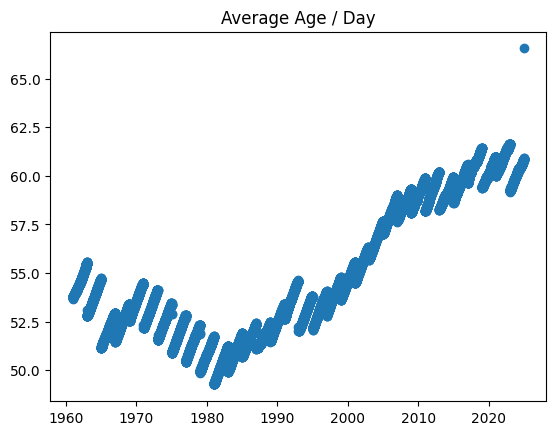

In [ ]:
# Make a scatterplot with x-axis = date and y-axis = average_age
import matplotlib.pyplot as plt
y = results_df_vectorized['median_age']
x = results_df_vectorized['date']

plt.scatter(x, y)
plt.title('Median Age / Day')



In [13]:
# Identify the outlier in the top right corner
# Sort by average_age descending to find the highest values
top_ages = results_df_vectorized.nlargest(10, 'average_age')[['date', 'average_age', 'min_age', 'max_age', 'median_age']]
print("Top 10 days with highest average age:")
print(top_ages)
print("\n")

# Check the last dates in the dataset (right side of plot)
print("Last 10 dates in dataset:")
print(results_df_vectorized.tail(10)[['date', 'average_age']])

Top 10 days with highest average age:
            date  average_age  min_age  max_age  median_age
23376 2025-01-03       64.446   45.123   81.248      66.548
22641 2022-12-30       60.848   27.414   89.522      61.655
22640 2022-12-29       60.845   27.411   89.520      61.652
22639 2022-12-28       60.842   27.409   89.517      61.650
22638 2022-12-27       60.840   27.406   89.514      61.647
22637 2022-12-26       60.837   27.403   89.511      61.644
22636 2022-12-25       60.834   27.400   89.509      61.641
22635 2022-12-24       60.831   27.398   89.506      61.639
22634 2022-12-23       60.829   27.395   89.503      61.636
22633 2022-12-22       60.826   27.392   89.500      61.633


Last 10 dates in dataset:
            date  average_age
23367 2024-12-25       60.393
23368 2024-12-26       60.396
23369 2024-12-27       60.399
23370 2024-12-28       60.402
23371 2024-12-29       60.404
23372 2024-12-30       60.407
23373 2024-12-31       60.410
23374 2025-01-01       60.446
2337

In [15]:
# Create a new dataframe using only the day 14 of each month
day_14_df = results_df_vectorized[results_df_vectorized['date'].dt.day == 14]
day_14_df.head()

,date,average_age,min_age,max_age,median_age,std_dev,q1_age,q3_age
11,1961-01-14,53.792,31.348,86.056,53.725,10.767,45.383,61.527
42,1961-02-14,53.900,31.433,86.141,53.864,10.763,45.524,61.617
70,1961-03-14,53.957,31.510,86.218,53.886,10.763,45.585,61.663
101,1961-04-14,54.042,31.595,86.303,53.971,10.763,45.669,61.747
131,1961-05-14,54.097,31.677,86.385,53.999,10.773,45.687,61.808


Text(0.5, 1.0, 'Median Age / Day')

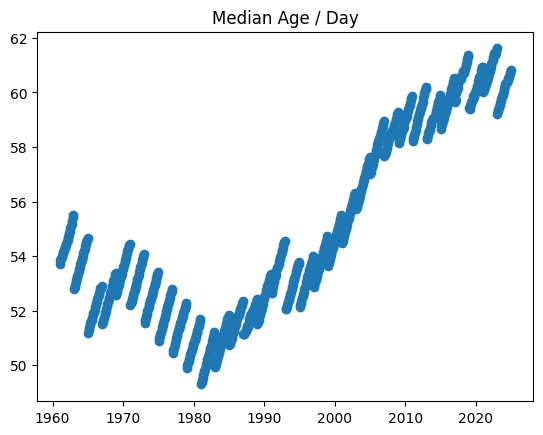

In [16]:
# Make a scatterplot with x-axis = date and y-axis = average_age
import matplotlib.pyplot as plt
y = day_14_df['median_age']
x = day_14_df['date']

plt.scatter(x, y)
plt.title('Median Age / Day')

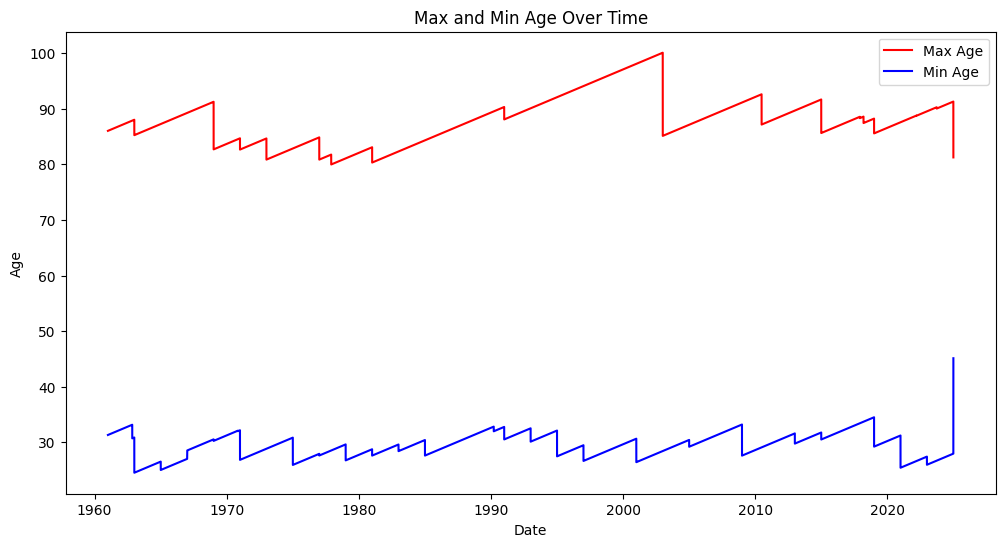

In [17]:
# Make a chart of the max and min age over time
plt.figure(figsize=(12, 6))
plt.plot(results_df_vectorized['date'], results_df_vectorized['max_age'], label='Max Age', color='red')
plt.plot(results_df_vectorized['date'], results_df_vectorized['min_age'], label='Min Age', color='blue')
plt.xlabel('Date')
plt.ylabel('Age')
plt.title('Max and Min Age Over Time')
plt.legend()
plt.show()

In [20]:
# save day_14_df as a .csv
day_14_df.to_excel("..\\data\\processed\\day_14_df.xlsx")